In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("placementdata.csv")

df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,CodingScore,CommunicationScore
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced,72,75
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed,62,68
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced,74,77
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed,87,88
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed,61,67


In [5]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(10000, 12)


In [6]:
print(df.columns)

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [8]:
df.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [9]:
print(df.duplicated().sum())

0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
CGPA,10000.0,7.69801,0.640131,6.5,7.40,7.7,8.20,9.1
Internships,10000.0,1.04920,0.665901,0.0,1.00,1.0,1.00,2.0
Projects,10000.0,2.02660,0.867968,0.0,1.00,2.0,3.00,3.0
Workshops/Certifications,10000.0,1.01320,0.904272,0.0,0.00,1.0,2.00,3.0
AptitudeTestScore,10000.0,79.44990,8.159997,60.0,73.00,80.0,87.00,90.0
SoftSkillsRating,10000.0,4.32396,0.411622,3.0,4.00,4.4,4.70,4.8
SSC_Marks,10000.0,69.15940,10.430459,55.0,59.00,70.0,78.00,90.0
HSC_Marks,10000.0,74.50150,8.919527,57.0,67.00,73.0,83.00,88.0


In [12]:
print(df["CGPA"].mean())


7.698010000000001


In [8]:
df["CGPA"].median()

np.float64(7.7)

In [7]:
df["Internships"].mode()

0    1
Name: Internships, dtype: int64

In [ ]:
print(df["CodingScore"].std())

In [9]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print(correlation)

                          StudentID      CGPA  Internships  Projects  \
StudentID                  1.000000  0.005724     0.015655  0.015924   
CGPA                       0.005724  1.000000     0.280601  0.435928   
Internships                0.015655  0.280601     1.000000  0.309196   
Projects                   0.015924  0.435928     0.309196  1.000000   
Workshops/Certifications   0.011872  0.349686     0.279110  0.377865   
AptitudeTestScore          0.020314  0.461250     0.320725  0.540339   
SoftSkillsRating          -0.002269  0.383547     0.273691  0.450294   
SSC_Marks                 -0.003082  0.404971     0.279837  0.499421   
HSC_Marks                  0.024115  0.462313     0.317149  0.535708   
CodingScore               -0.009625  0.011563     0.007486  0.013107   
CommunicationScore        -0.010029  0.011771     0.008250  0.012567   

                          Workshops/Certifications  AptitudeTestScore  \
StudentID                                 0.011872           0

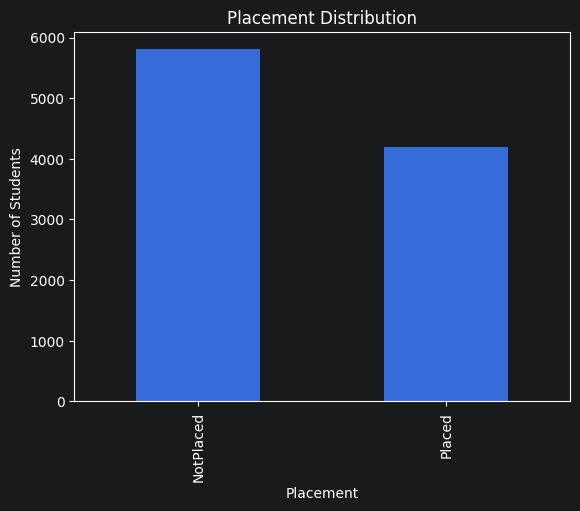

In [20]:
df["PlacementStatus"].value_counts().plot(kind="bar")

plt.title("Placement Distribution")

plt.xlabel("Placement")

plt.ylabel("Number of Students")

plt.show()

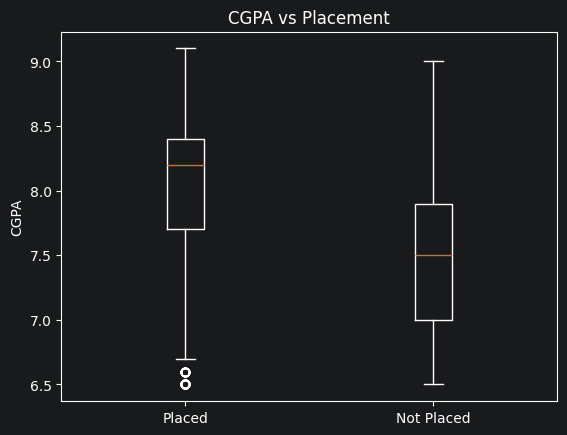

In [13]:
placed = df[df["PlacementStatus"] == "Placed"]["CGPA"]
not_placed = df[df["PlacementStatus"] == "NotPlaced"]["CGPA"]

plt.boxplot([placed, not_placed], tick_labels=["Placed", "Not Placed"])

plt.title("CGPA vs Placement")

plt.ylabel("CGPA")

plt.show()

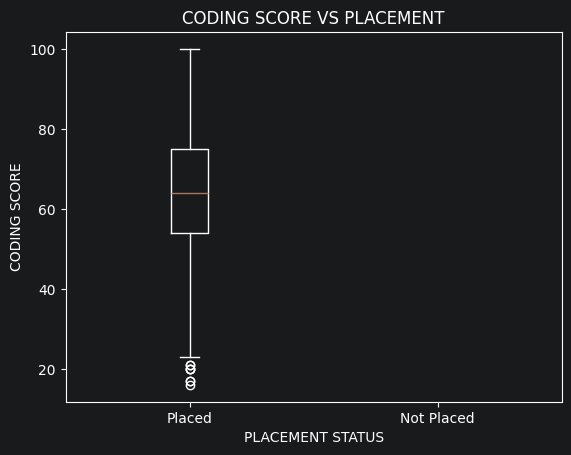

In [18]:

placed = df[df["PlacementStatus"] == "Placed"]["CodingScore"]
not_placed = df[df["PlacementStatus"] == "Not Placed"]["CodingScore"]

plt.boxplot([placed, not_placed], tick_labels=["Placed", "Not Placed"])
plt.title("CODING SCORE VS PLACEMENT")
plt.xlabel("PLACEMENT STATUS")
plt.ylabel("CODING SCORE")

# Show the plot
plt.show()


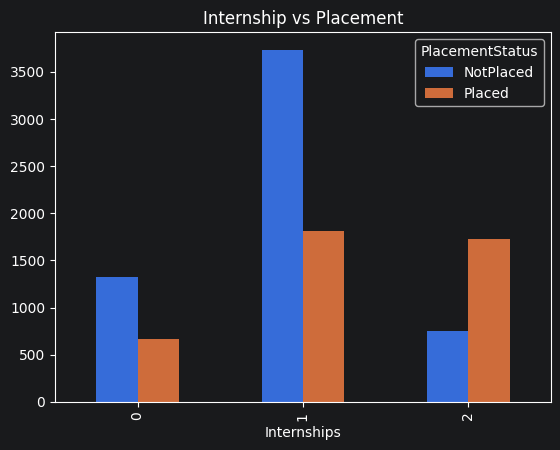

In [28]:
pd.crosstab(df["Internships"], df["PlacementStatus"]).plot(kind="bar")

plt.title("Internship vs Placement")

plt.show()

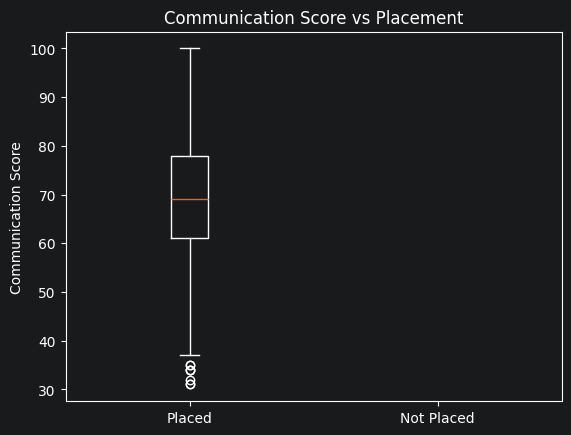

In [33]:
placed = df[df["PlacementStatus"] == "Placed"]["CommunicationScore"]
not_placed = df[df["PlacementStatus"] == "Not Placed"]["CommunicationScore"]

plt.boxplot([placed, not_placed], tick_labels=["Placed", "Not Placed"])

plt.title("Communication Score vs Placement")

plt.ylabel("Communication Score")

plt.show()

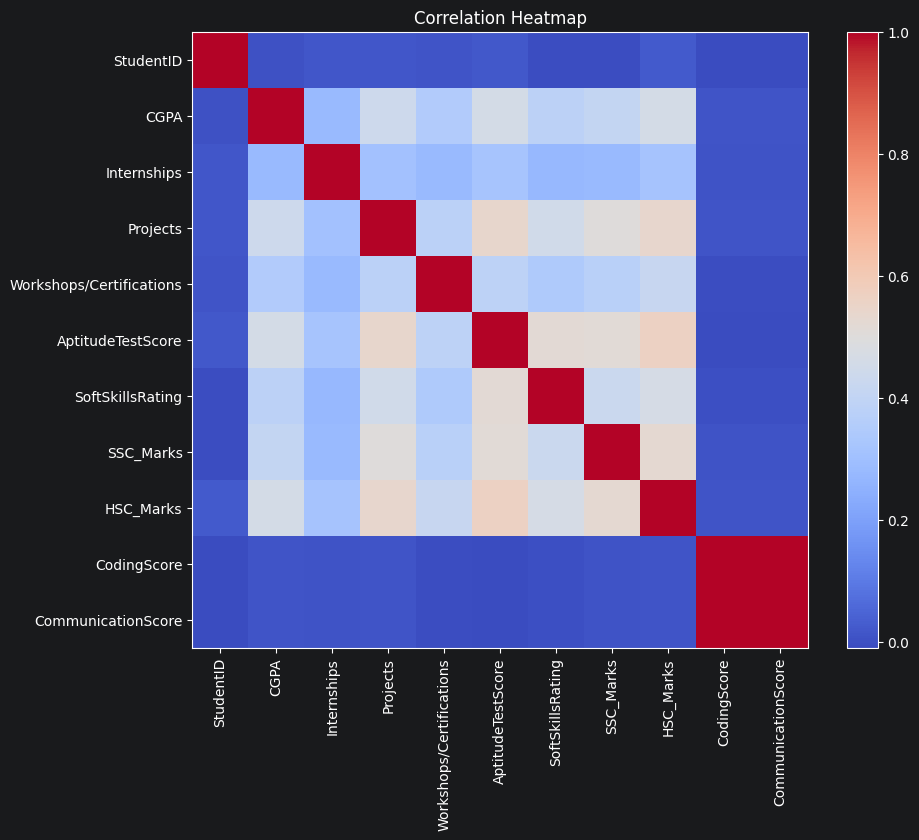

In [26]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()